# Case Studies

This notebook compares different ML retrievals for two case studies from the SatRain benchmark dataset.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

## Baselines

In [2]:
from satrain.evaluation import Evaluator
from satrain.input import parse_retrieval_inputs
from satrain.target import TargetConfig

retrieval_input = parse_retrieval_inputs([
    {"name": "ancillary"},
    {"name": "gmi"}
])
target_config = TargetConfig(min_rqi=0.5)
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)
evaluator_korea = Evaluator(
    domain="korea",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)

### GPROF V08

In [3]:
from gprof_nn.satrain import GPROFNNRetrieval

gprof_v08_retrieval = GPROFNNRetrieval(
    sensor="gmi"
)

In [4]:
res_gprof_v08_conus = evaluator_conus.evaluate_scene(811, None, 0, None, gprof_v08_retrieval, input_data_format="spatial")
res_gprof_v08_korea = evaluator_korea.evaluate_scene(516, None, 0, None, gprof_v08_retrieval, input_data_format="spatial")

### ERA5

In [5]:
from satrain.input import Ancillary
anc = Ancillary(variables=["total_precipitation"])

def era5_retrieval(input_data: xr.Dataset) -> xr.Dataset:
    """
    Retrieval callback function to load GPROF data corresponding to IPWGML SPR evaluation data.

    Args:
        input_data: An xarray.Dataset containing the retrieval input data.

    Return:
        An xarray.Dataset containing the retrieval results.
    """
    tp = 1e3 * input_data.ancillary[0].data
    precip_flag = 0.1 < tp
    heavy_precip_flag = 10 < tp
        
    return xr.Dataset({
        "surface_precip": (("latitude", "longitude"), tp),
        "precip_flag": (("latitude", "longitude"), precip_flag),
        "heavy_precip_flag": (("latitude", "longitude"), heavy_precip_flag),
    })

In [6]:
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[anc],
    download=True,
    target_config=target_config,
)
evaluator_korea = Evaluator(
    domain="korea",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=[anc],
    download=True,
    target_config=target_config,
)

res_era5_conus = evaluator_conus.evaluate_scene(811, None, 0, None, era5_retrieval, input_data_format="spatial")
res_era5_korea = evaluator_korea.evaluate_scene(516, None, 0, None, era5_retrieval, input_data_format="spatial")

## GPROF-IR

In [7]:
from gprof_ir.satrain import GPROFIRRetrieval
gprof_ir_retrieval = GPROFIRRetrieval(
    ["/data2/satellite_data/gpm/merged_ir/", "/data3/satellite_data/gpm/merged_ir/"],
    variant="gmi",
    n_steps=3,
    device="cuda:0",
    dtype="bfloat16"
)

In [8]:
res_gprof_ir_conus = evaluator_conus.evaluate_scene(811, None, 0, None, gprof_ir_retrieval, input_data_format="spatial")
res_gprof_ir_korea = evaluator_korea.evaluate_scene(516, None, 0, None, gprof_ir_retrieval, input_data_format="spatial")

## Pixel-Based Retrievals

### BMCI

In [2]:
from satrain_models.config import SatRainConfig
from satrain_models.datamodule import SatRainDataModule
from satrain_models.bmci_fast import BMCIc

satrain_cfg = SatRainConfig(
    base_sensor="gmi",
    geometry="on_swath",
    subset="xl",
    format="spatial",
    retrieval_input=[{
        "name": "gmi",
        "include_angles": False
    }]
)
data_module = SatRainDataModule(satrain_cfg)
bmci_model = BMCIc.load("../models/bmci/models/bmci_gmi_gmi_on_swath_m_tabular_smean1600_c3000_v0.nc")
bmci_retrieval = bmci_model.create_retrieval_fn(
    satrain_cfg,
    data_module
)

INFO     OpenMP enabled with 16 maximum threads

In [3]:
from satrain.evaluation import Evaluator
from satrain.input import parse_retrieval_inputs
from satrain.target import TargetConfig
retrieval_input = parse_retrieval_inputs([{"name": "gmi", "include_angles": False}])
target_config = TargetConfig(min_rqi=0.5)
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)
evaluator_korea = Evaluator(
    domain="korea",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)


In [4]:
res_bmci_korea = evaluator_korea.evaluate_scene(516, None, 0, None, bmci_retrieval, input_data_format="tabular")

KeyboardInterrupt: 

In [20]:
res_bmci_conus = evaluator_conus.evaluate_scene(811, None, 0, None, bmci_retrieval, input_data_format="tabular")
res_bmci_korea = evaluator_korea.evaluate_scene(516, None, 0, None, bmci_retrieval, input_data_format="tabular")

In [37]:
res_bmci_conus.to_netcdf("res_bmci_conus.nc")
res_bmci_korea.to_netcdf("res_bmci_korea.nc")

In [15]:
data = evaluator_conus.get_input_data(811)

### Random Forest

In [38]:
retrieval_input = parse_retrieval_inputs([{"name": "gmi", "include_angles": False, "normalize": "minmax", "nan": -1.5}])
target_config = TargetConfig(min_rqi=0.5)
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)
evaluator_korea = Evaluator(
    domain="korea",
    base_sensor="gmi",
    geometry="on_swath",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)


In [ ]:
from satrain_models.random_

In [22]:
forest import RandomForestRetrieval
rf_retrieval = RandomForestRetrieval()
rf_retrieval.load_model(
    "../models/random_forest/models/random_forest_gmi_gmi_on_swath_s_tabular_n100_dnull_split2_leaf1_featsqrt_v0.joblib",
)
rf_retrieval = rf_retrieval.get_retrieval_fn(retrieval_input=retrieval_input)

In [39]:
res_rf_conus = evaluator_conus.evaluate_scene(811, None, 0, None, rf_retrieval, input_data_format="tabular")
res_rf_korea = evaluator_korea.evaluate_scene(516, None, 0, None, rf_retrieval, input_data_format="tabular")

### XGBoost

In [40]:
from satrain_models.xgboost import XGBoostRetrieval
xgb_retrieval = XGBoostRetrieval()
xgb_retrieval.load_model(
    "../models/xgboost/models/xgboost_gmi_gmi_on_swath_m_tabular_n1000_d6_lr0100_sub080_col080_v0.xgb"
)
xgb_retrieval = xgb_retrieval.get_retrieval_fn(retrieval_input=retrieval_input)

/home/simon/src/satrain_models/satrain_models/xgboost.py:238: UserWarning: [15:29:58] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.model.load_model(path)


In [41]:
res_xgb_conus = evaluator_conus.evaluate_scene(811, None, 0, None, xgb_retrieval, input_data_format="tabular")
res_xgb_korea = evaluator_korea.evaluate_scene(516, None, 0, None, xgb_retrieval, input_data_format="tabular")

### Fully-Connected

In [42]:
from satrain_models.config import SatRainConfig, ComputeConfig
from satrain_models.lightning import SatRainEstimationModule
from satrain_models.fully_connected import load_model

satrain_cfg = SatRainConfig(
    base_sensor="gmi",
    geometry="gridded",
    subset="xl",
    format="spatial",
    retrieval_input=[{
        "name": "gmi",
        "normalize": "minmax",
        "nan": -1.5,
        "include_angles": False
    }]
)


mlp = load_model("../models/fully_connected//models/fully_connected_gmi_gmi_on_swath_xl_tabular_128x128x128_nodrop_adamw_warmup_cosine_annealing_restarts_v01.pt")
lightning_module = SatRainEstimationModule(model=mlp)
compute_cfg = ComputeConfig(
    approach="sgd",
    max_epochs=0,
    batch_size=16,
    num_workers=0,
    accelerator="cpu",
    precision="bf16-mixed"
)
mlp_retrieval = lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg, )

In [43]:
res_mlp_conus = evaluator_conus.evaluate_scene(811, 256, 64, 8, mlp_retrieval, input_data_format="tabular")
res_mlp_korea = evaluator_korea.evaluate_scene(516, 256, 64, 8, mlp_retrieval, input_data_format="tabular")

## Spatially Resolved Retrievals

In [44]:
target_config = TargetConfig(min_rqi=0.5)
evaluator_conus = Evaluator(
    domain="conus",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)
evaluator_korea = Evaluator(
    domain="korea",
    base_sensor="gmi",
    geometry="gridded",
    retrieval_input=retrieval_input,
    download=True,
    target_config=target_config,
)

### UNet

In [45]:
from satrain_models.config import SatRainConfig, ComputeConfig
from satrain_models.lightning import SatRainEstimationModule
from satrain_models.unet import load_model

satrain_cfg = SatRainConfig(
    base_sensor="gmi",
    geometry="gridded",
    subset="xl",
    format="spatial",
    retrieval_input=[{
        "name": "gmi",
        "normalize": "minmax",
        "nan": -1.5,
        "include_angles": False
    }]
)


unet = load_model("../models/basic_unet/models/unet_gmi_gmi_gridded_xl_adamw_reduce_on_plateau_v03.pt")
lightning_module = SatRainEstimationModule(model=unet)
compute_cfg = ComputeConfig(
    approach="sgd",
    max_epochs=0,
    batch_size=16,
    num_workers=0,
    accelerator="cpu",
    precision="bf16-mixed"
)
unet_retrieval = lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg, )

In [46]:
res_unet_conus = evaluator_conus.evaluate_scene(811, 256, 64, 8, unet_retrieval, input_data_format="spatial")
res_unet_korea = evaluator_korea.evaluate_scene(516, 256, 64, 8, unet_retrieval, input_data_format="spatial")

### UNet*

In [47]:
from satrain_models.config import SatRainConfig, ComputeConfig
from satrain_models.lightning import SatRainEstimationModule
from satrain_models.unet import load_model

unet = load_model("../models/basic_unet/models/unet_gmi_gmi_gridded_xl_sgd_cosine_annealing_restarts_v03.pt")
lightning_module = SatRainEstimationModule(model=unet)
compute_cfg = ComputeConfig(
    approach="sgd",
    max_epochs=0,
    batch_size=16,
    num_workers=0,
    accelerator="cuda",
    devices=[0],
    precision="bf16-mixed"
)
unetx_retrieval = lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg, )

In [48]:
res_unetx_conus = evaluator_conus.evaluate_scene(811, 256, 64, 8, unetx_retrieval, input_data_format="spatial")
res_unetx_korea = evaluator_korea.evaluate_scene(516, 256, 64, 8, unetx_retrieval, input_data_format="spatial")

## UNet**

In [49]:
from satrain_models.config import SatRainConfig, ComputeConfig
from satrain_models.lightning import SatRainEstimationModule
from satrain_models.encoder_decoder import load_model

unetxx, satrain_cfg = load_model("../models/encoder_decoder/models/encoder_decoder_gmi_gmi_gridded_xl_residual_in13_ch76x152x304x608_d3_out1_bilinear_adamw_cosine_annealing_restarts_v00.pt")
lightning_module = SatRainEstimationModule(model=unetxx)

compute_cfg = ComputeConfig(
    approach="sgd",
    max_epochs=0,
    batch_size=16,
    num_workers=0,
    accelerator="cpu",
    precision="bf16-mixed"
)
unetxx_retrieval = lightning_module.get_retrieval_fn(satrain_cfg, compute_cfg, )


In [50]:
res_unetxx_conus = evaluator_conus.evaluate_scene(811, 256, 64, 8, unetxx_retrieval, input_data_format="spatial")
res_unetxx_korea = evaluator_korea.evaluate_scene(516, 256, 64, 8, unetxx_retrieval, input_data_format="spatial")

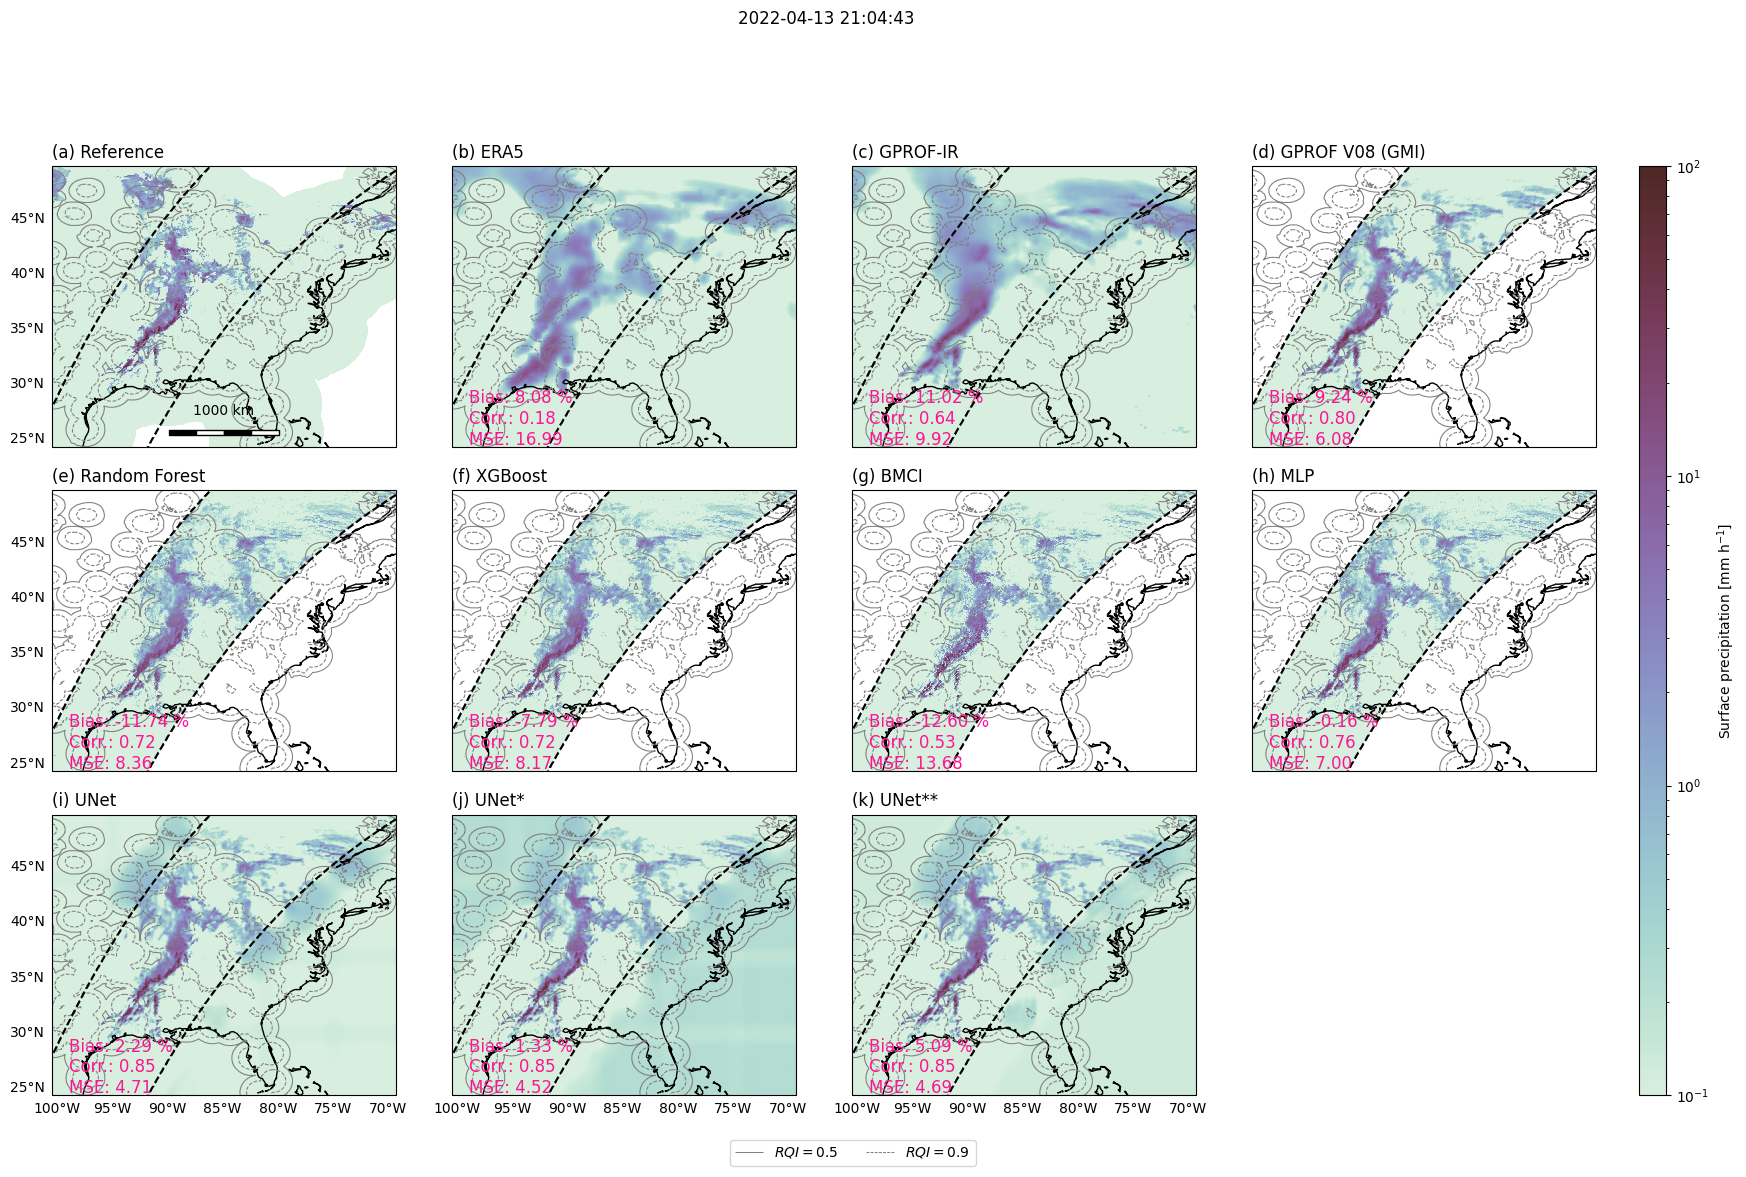

In [52]:
evaluator_conus.plot_retrieval_results(
    811,
    {
        "ERA5": res_era5_conus,
        "GPROF-IR": res_gprof_ir_conus,
        "GPROF V08 (GMI)": res_gprof_v08_conus,
        "Random Forest": res_rf_conus,
        "XGBoost": res_xgb_conus,
        "BMCI": res_bmci_conus,
        "MLP": res_mlp_conus,
        "UNet": res_unet_conus,
        "UNet*": res_unetx_conus,
        "UNet**": res_unetxx_conus,
    },
    include_metrics=True,
    swath_boundaries=True,
    n_rows=3
);

/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/simon/miniforge3/envs/satrain_models/lib/python3.11/site-packages/numpy/lib/function_base.py:2

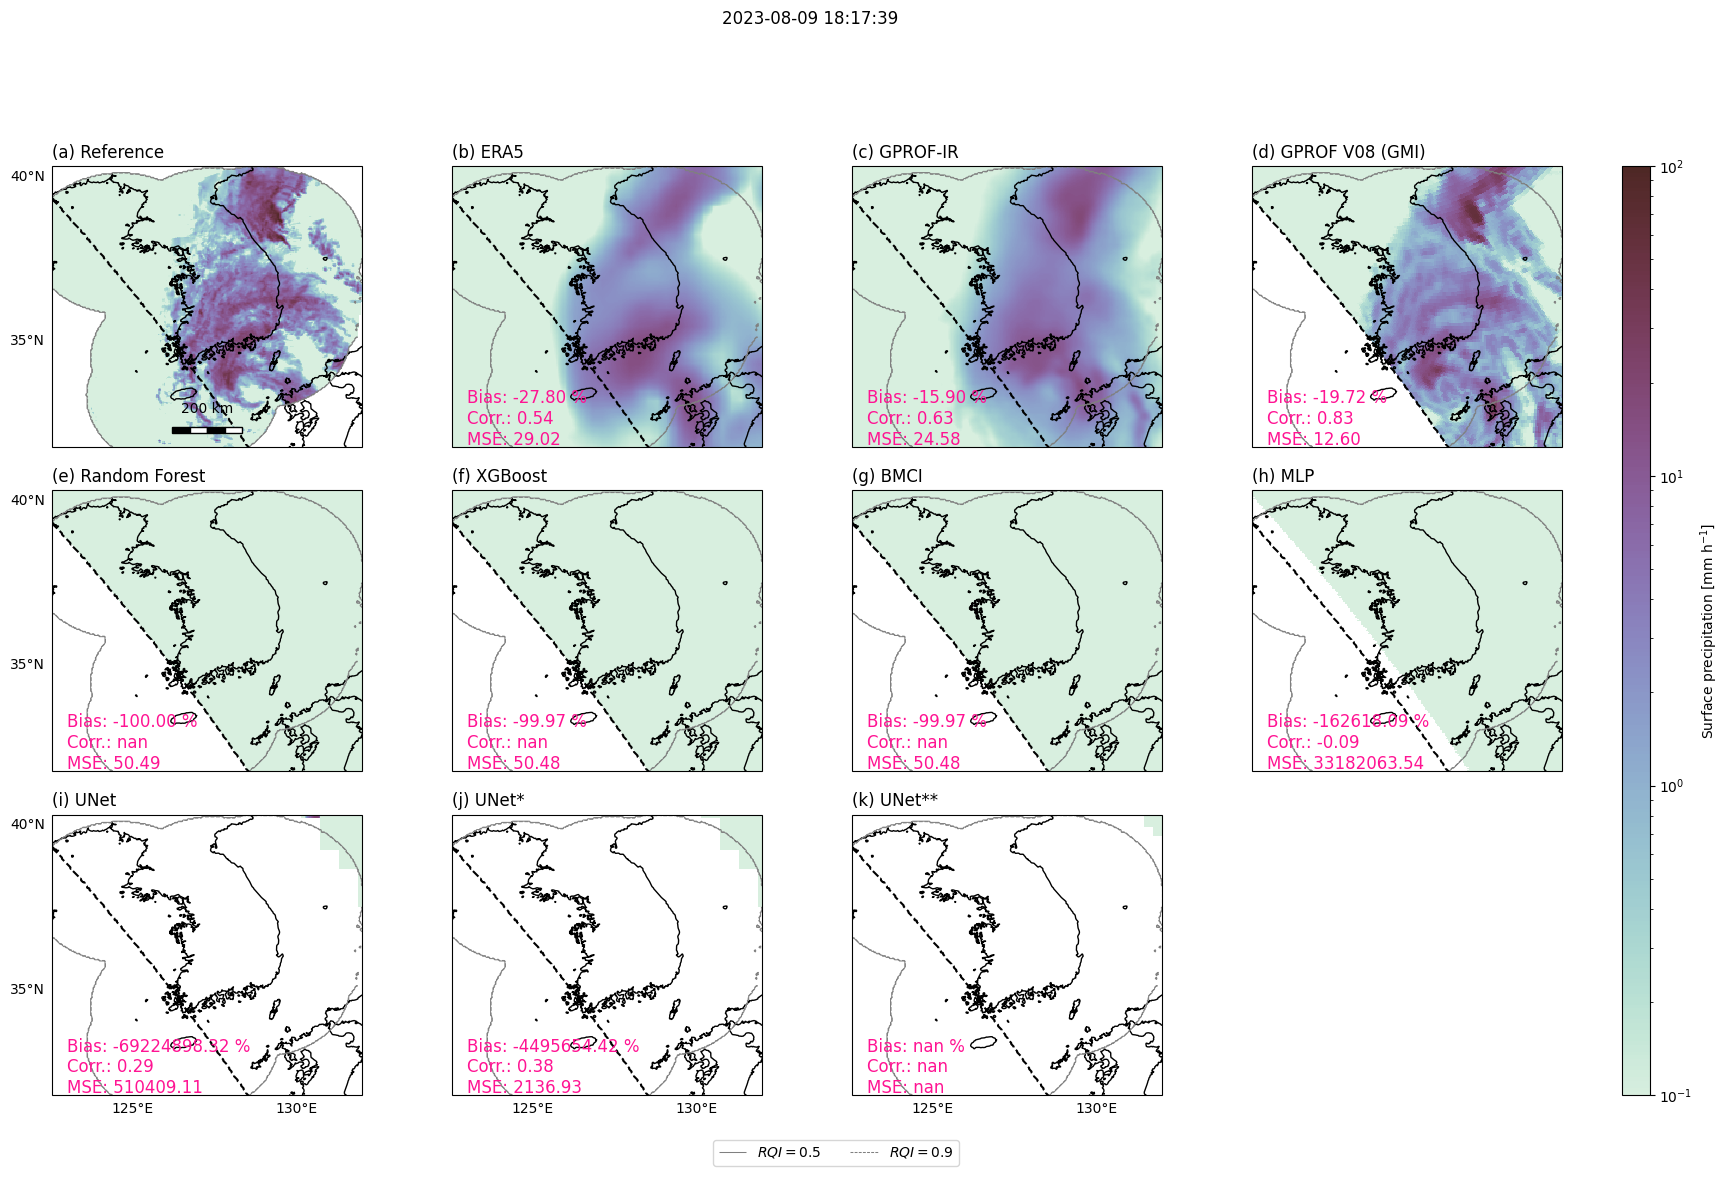

In [36]:
evaluator_korea.plot_retrieval_results(
    516,
    {
        "ERA5": res_era5_korea,
        "GPROF-IR": res_gprof_ir_korea,
        "GPROF V08 (GMI)": res_gprof_v08_korea,
        "Random Forest": res_rf_korea,
        "XGBoost": res_xgb_korea,
        "BMCI": res_xgb_korea,
        "MLP": res_mlp_korea,
        "UNet": res_unet_korea,
        "UNet*": res_unetx_korea,
        "UNet**": res_unetxx_korea,
    },
    include_metrics=True,
    swath_boundaries=True,
    n_rows=3
);

In [ ]:

evaluator_korea.plot_retrieval_results(
    516,
    {
        "Random Forest": res_rf_korea,
        "XGBoost": res_xgb_korea,
        "UNet": res_unet_korea,
        "UNet*": res_unetx_korea,
        "UNet**": res_unetxx_korea,
    },
    include_metrics=True,
    swath_boundaries=True,
    n_rows=2
);

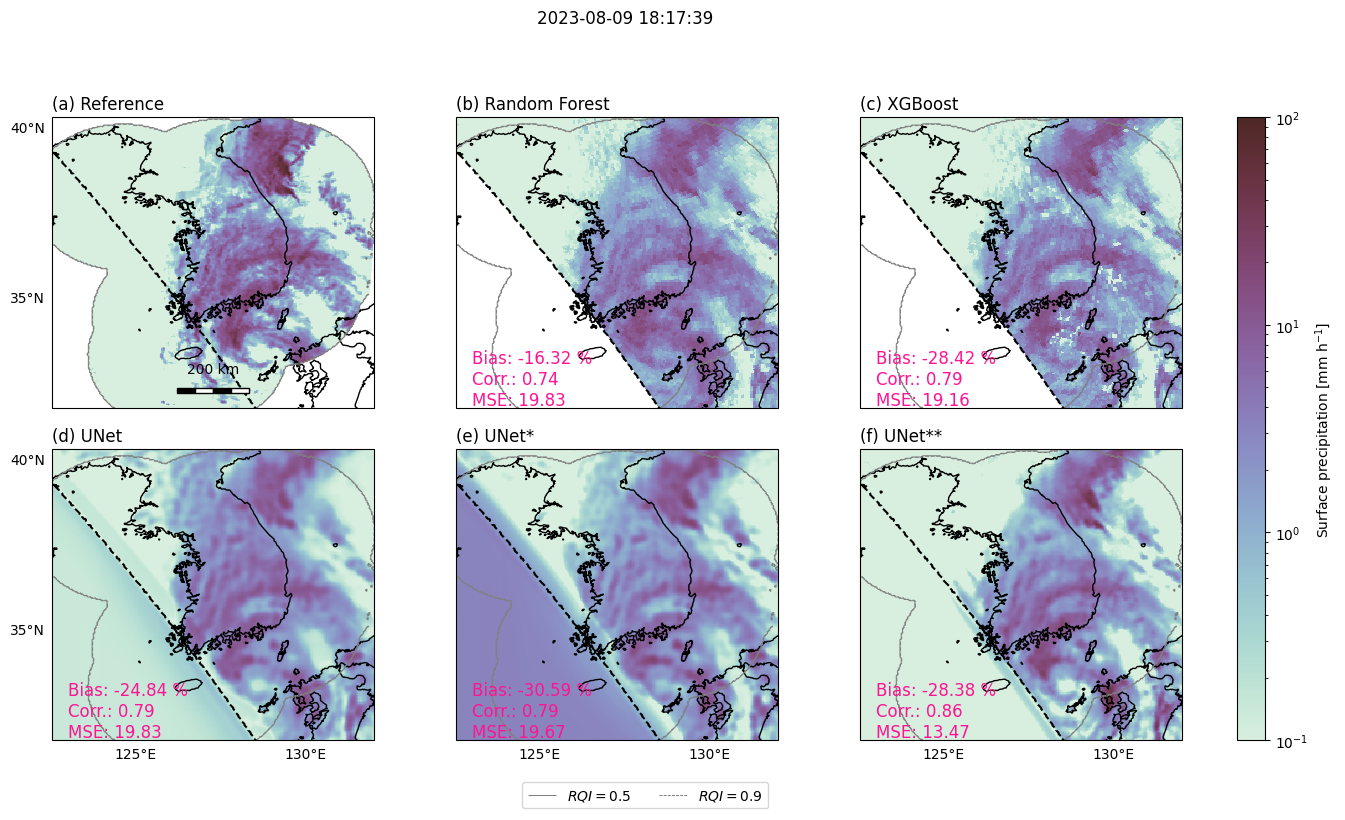

In [53]:
evaluator_korea.plot_retrieval_results(
    516,
    {
        "Random Forest": res_rf_korea,
        "XGBoost": res_xgb_korea,
        "UNet": res_unet_korea,
        "UNet*": res_unetx_korea,
        "UNet**": res_unetxx_korea,
    },
    include_metrics=True,
    swath_boundaries=True,
    n_rows=2
);